# MNIST Handwritten Digit Recognition

Notebook version of the latest modular pipeline. It loads cached MNIST data, generates the PCA and t-SNE visuals, trains the three selected models, and now includes the raw-vs-PCA benchmark artifacts used in the presentation.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from mnist_pipeline.config import build_config
from mnist_pipeline.data import load_processed_dataset
from mnist_pipeline.embeddings import generate_embedding_artifacts, save_sample_grid
from mnist_pipeline.reporting import save_run_manifest
from mnist_pipeline.training import train_and_evaluate_models


In [2]:
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

args = SimpleNamespace(
    project_root=project_root,
    pca_sample_size=5000,
    tsne_sample_size=3000,
    validation_fraction=0.15,
    random_state=42,
)
config = build_config(args)
config

PipelineConfig(project_root=PosixPath('/Users/bob/Desktop/MNIST'), raw_data_dir=PosixPath('/Users/bob/Desktop/MNIST/data/raw'), processed_data_dir=PosixPath('/Users/bob/Desktop/MNIST/data/processed'), raw_dataset_path=PosixPath('/Users/bob/Desktop/MNIST/data/raw/mnist.npz'), processed_dataset_path=PosixPath('/Users/bob/Desktop/MNIST/data/processed/mnist_flattened.npz'), artifacts_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts'), figures_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts/figures'), results_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts/results'), pca_sample_size=5000, tsne_sample_size=3000, validation_fraction=0.15, random_state=42)

In [3]:
X_train, X_test, y_train, y_test = load_processed_dataset(config=config, force_refresh=False)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(60000, 784) (10000, 784) (60000,) (10000,)


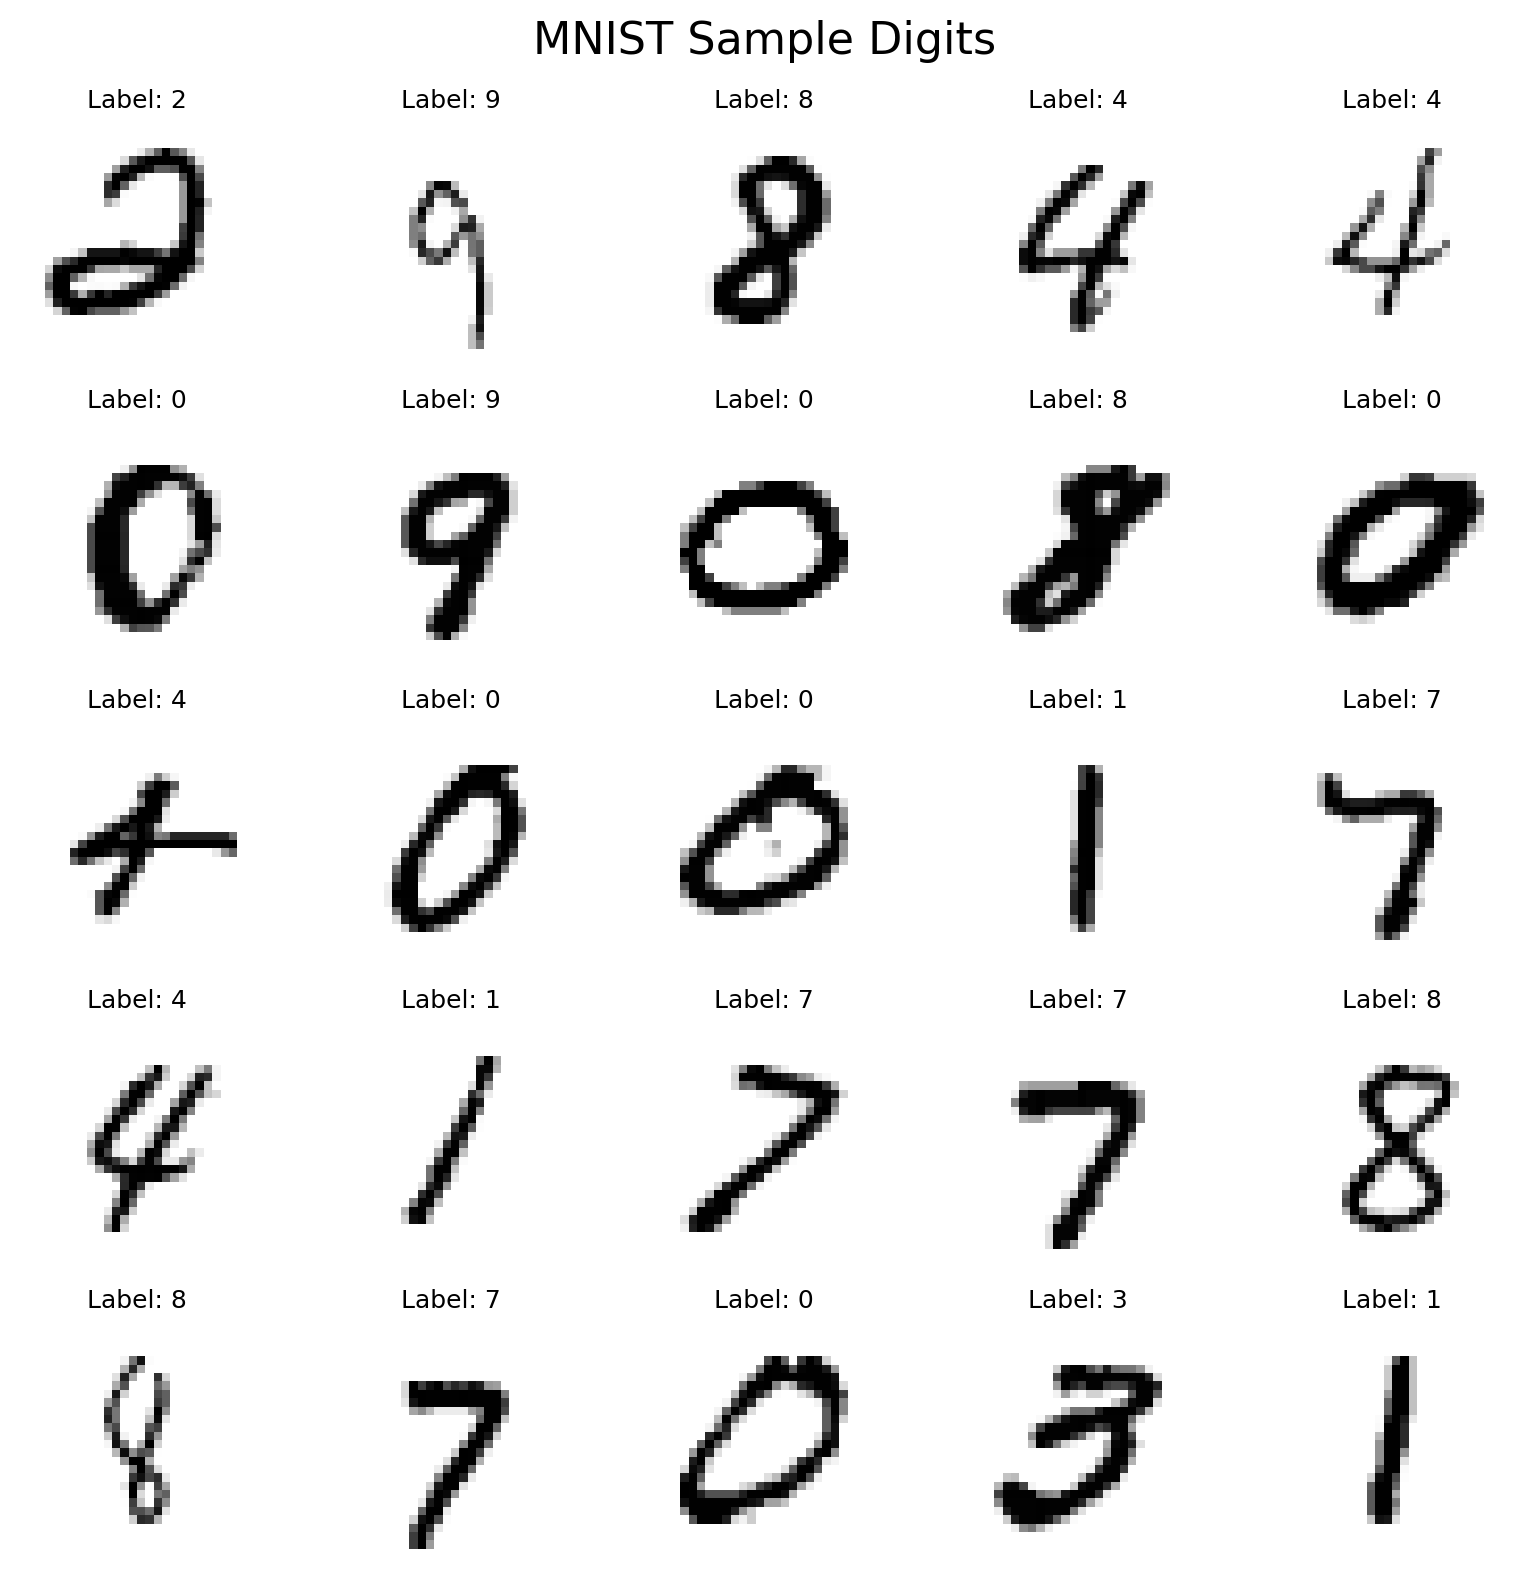

In [4]:
sample_path = config.figures_dir / 'sample_digits.png'
save_sample_grid(X_train, y_train, sample_path, random_state=config.random_state)
display(Image(filename=str(sample_path)))

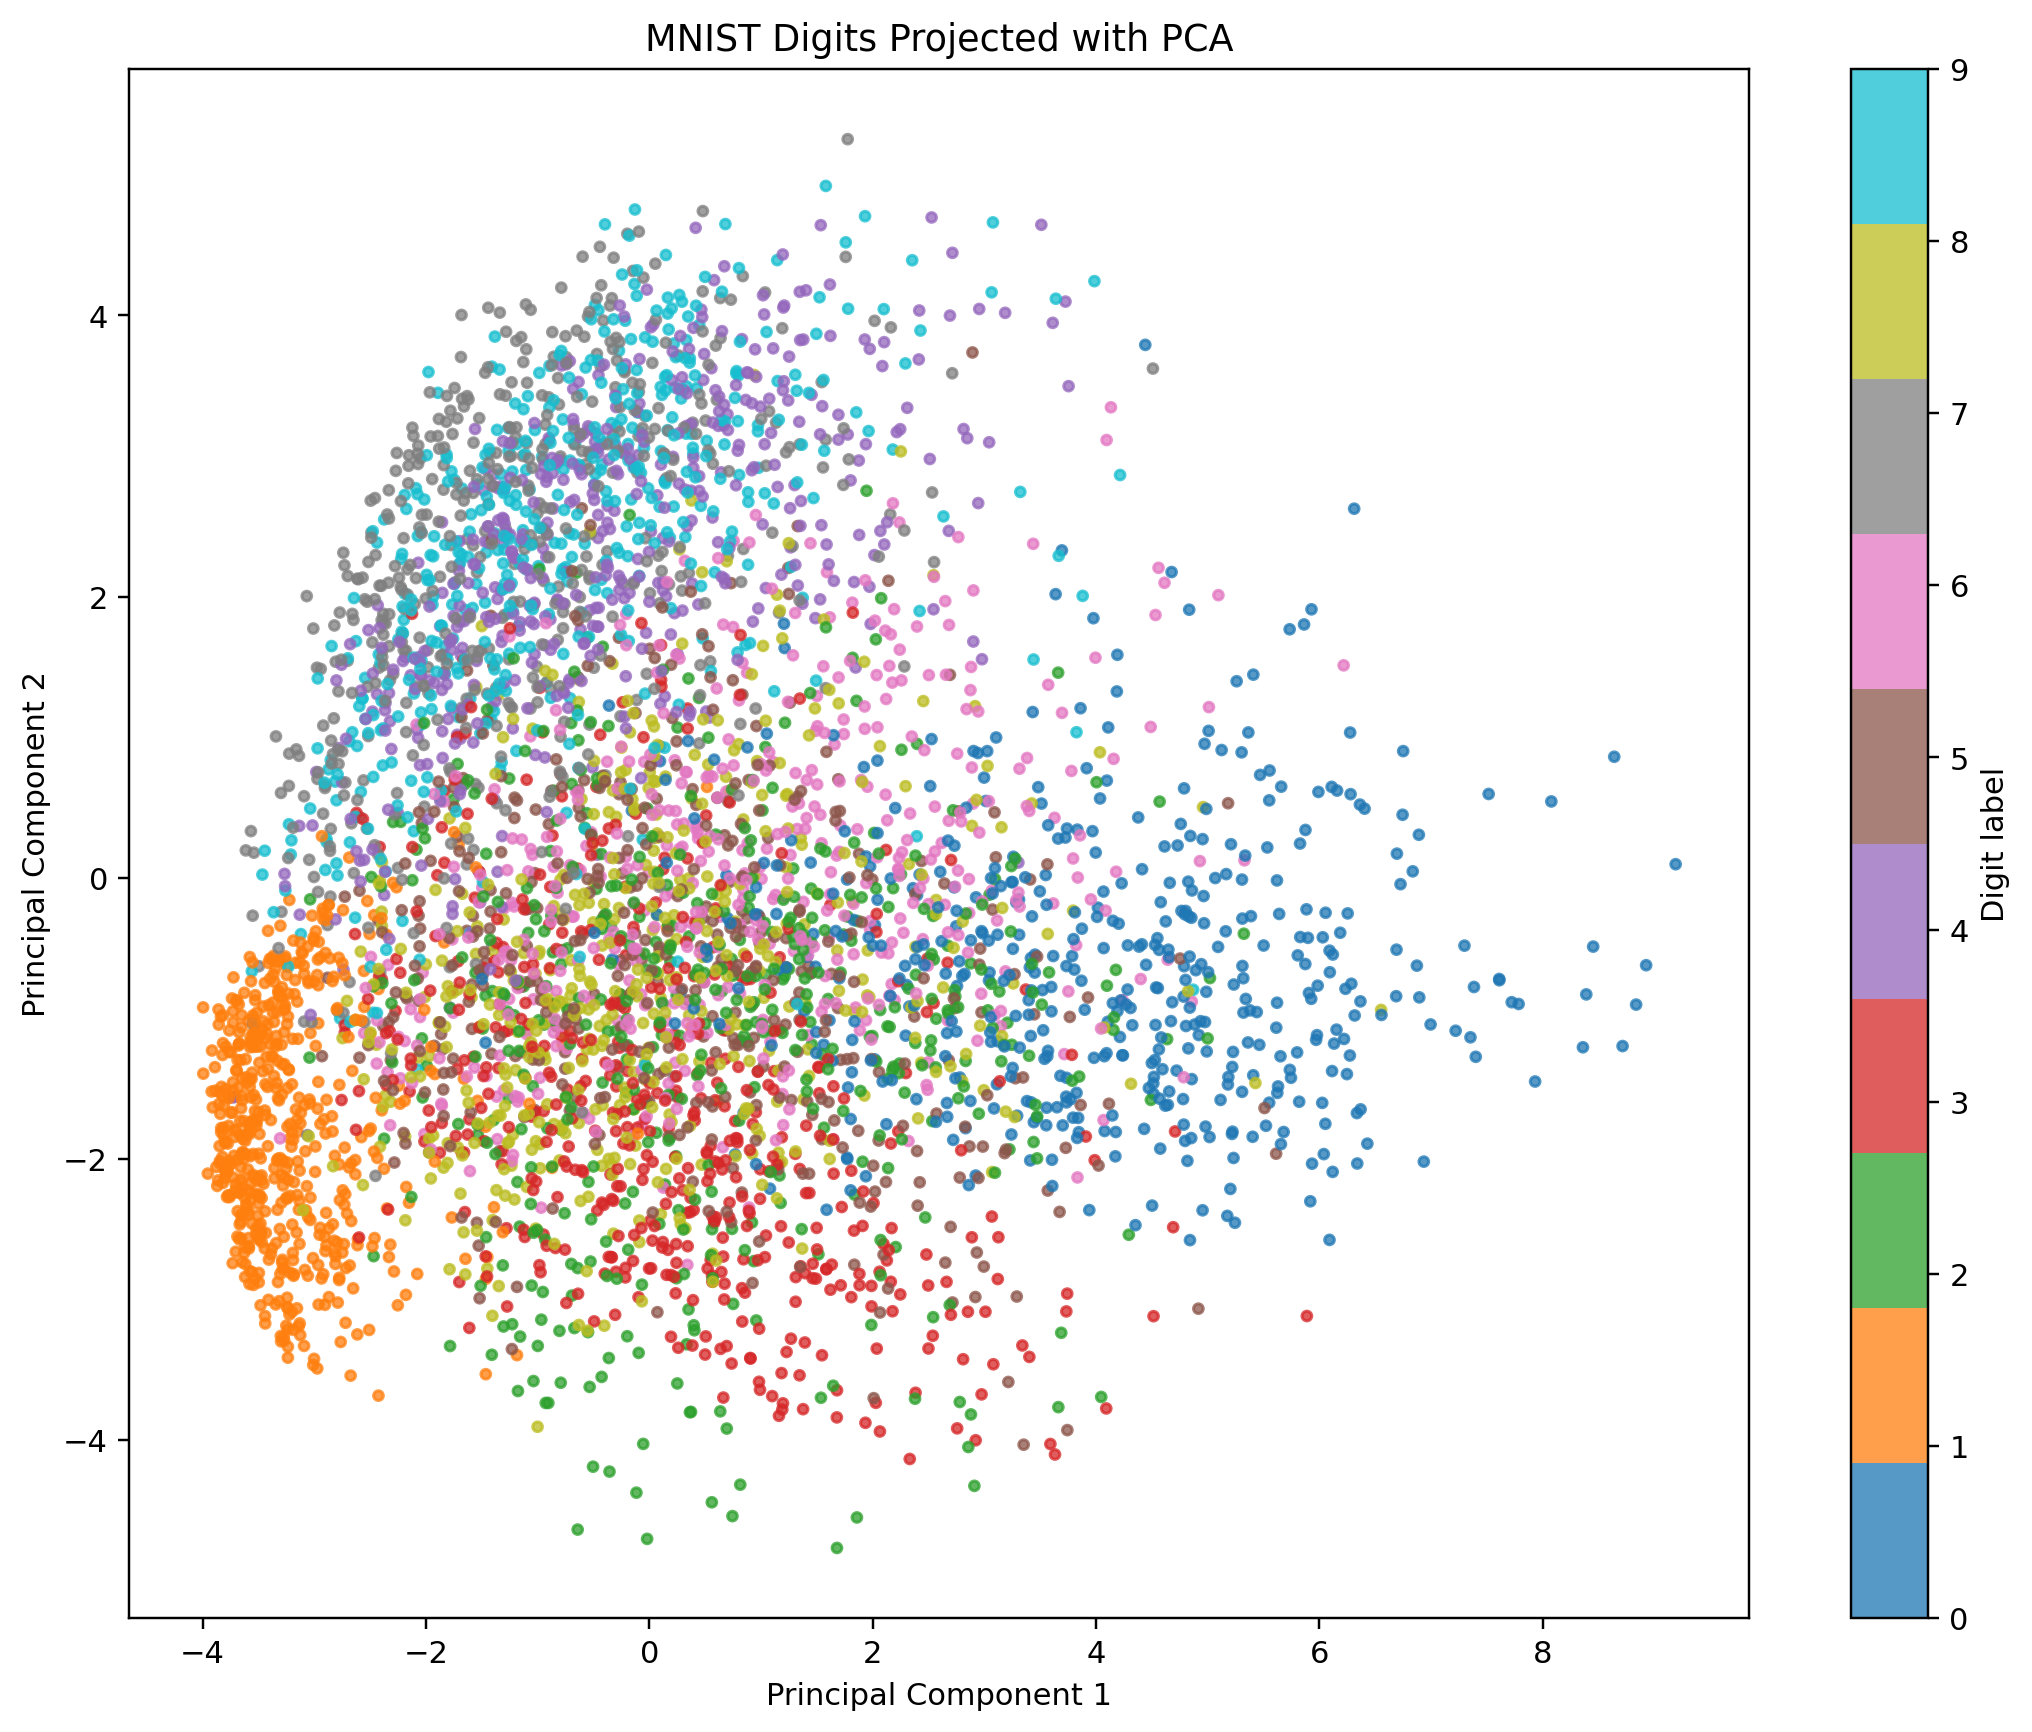

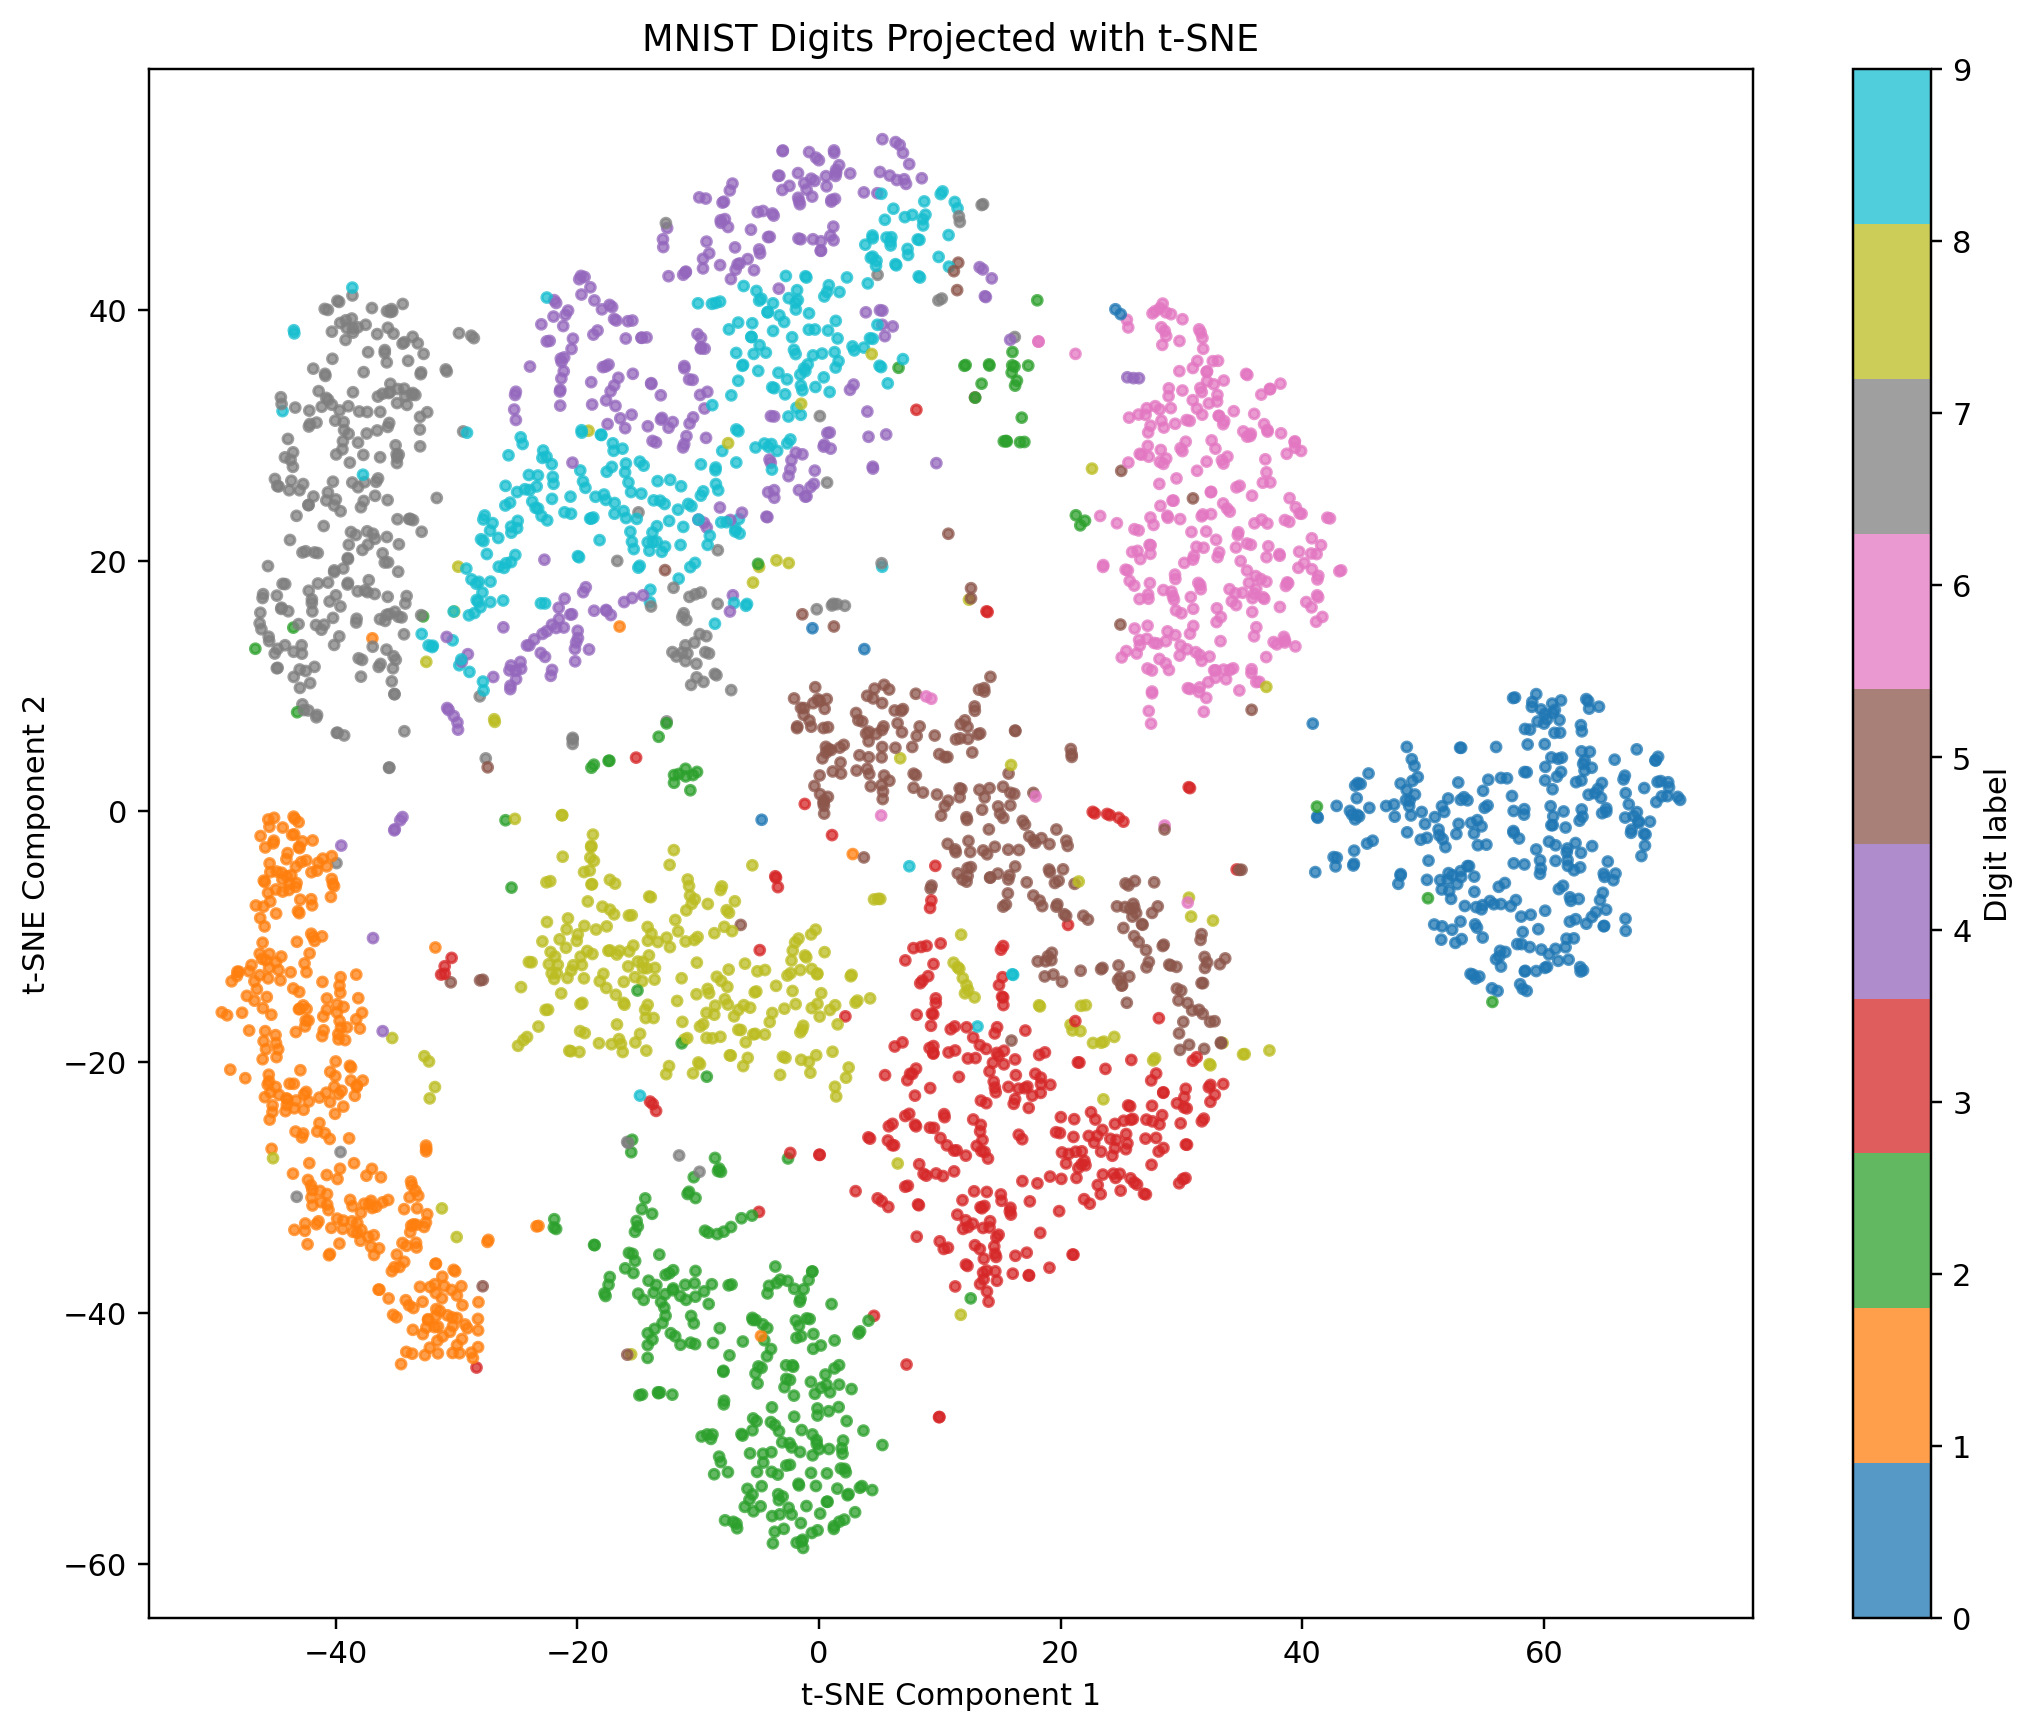

{'pca_explained_variance_ratio': 0.16922998428344727}

In [5]:
embedding_metadata = generate_embedding_artifacts(X_train, y_train, config)
display(Image(filename=str(config.figures_dir / 'digits_pca_2d.png')))
display(Image(filename=str(config.figures_dir / 'digits_tsne_2d.png')))
embedding_metadata

In [6]:
metrics_frame = train_and_evaluate_models(X_train, X_test, y_train, y_test, config)
save_run_manifest(config, metrics_frame, embedding_metadata, y_train, y_test)
metrics_frame

,model_key,model,selected_configuration,train_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro
2,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",4.014,0.006,0.9807,0.98062,0.98052,0.98056
0,knn,k-Nearest Neighbors,"k=3, weights=distance",0.018,2.123,0.9717,0.97190,0.97134,0.97153
1,logistic_regression,Logistic Regression,C=0.1,2.730,0.011,0.9257,0.92479,0.92459,0.92457


In [7]:
metrics_path = config.results_dir / 'model_metrics.csv'
selection_path = config.results_dir / 'model_selection_summary.csv'
pca_selection_path = config.results_dir / 'pca_selection_summary.csv'

display(pd.read_csv(metrics_path))
display(pd.read_csv(selection_path))
display(pd.read_csv(pca_selection_path))

,model_key,model,selected_configuration,train_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",4.014,0.006,0.9807,0.98062,0.98052,0.98056
1,knn,k-Nearest Neighbors,"k=3, weights=distance",0.018,2.123,0.9717,0.97190,0.97134,0.97153
2,logistic_regression,Logistic Regression,C=0.1,2.730,0.011,0.9257,0.92479,0.92459,0.92457


,model_key,model,selected_configuration,validation_accuracy,validation_f1_macro
0,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",0.97700,0.97693
1,knn,k-Nearest Neighbors,"k=3, weights=distance",0.97089,0.97083
2,logistic_regression,Logistic Regression,C=0.1,0.92178,0.92094


,model_key,model,selected_configuration,selected_pca_components,validation_accuracy,validation_f1_macro,explained_variance_ratio
0,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",100,0.97956,0.97945,0.91466
1,knn,k-Nearest Neighbors,"k=3, weights=distance",75,0.97611,0.97601,0.88288
2,logistic_regression,Logistic Regression,C=0.1,150,0.92022,0.91938,0.94839


,model_key,model,selected_configuration,representation_key,representation_label,is_pca,n_components,explained_variance_ratio,transform_seconds,train_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro,accuracy_delta_vs_raw
0,knn,k-Nearest Neighbors,"k=3, weights=distance",raw,Raw (784),False,784,1.00000,0.000,0.018,2.123,0.9717,0.97190,0.97134,0.97153,0.0000
1,knn,k-Nearest Neighbors,"k=3, weights=distance",pca_75,PCA (75),True,75,0.88283,0.065,0.002,0.362,0.9754,0.97541,0.97514,0.97523,0.0037
2,logistic_regression,Logistic Regression,C=0.1,raw,Raw (784),False,784,1.00000,0.000,2.730,0.011,0.9257,0.92479,0.92459,0.92457,0.0000
3,logistic_regression,Logistic Regression,C=0.1,pca_150,PCA (150),True,150,0.94835,0.076,0.526,0.001,0.9233,0.92222,0.92227,0.92218,-0.0024
4,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",raw,Raw (784),False,784,1.00000,0.000,4.014,0.006,0.9807,0.98062,0.98052,0.98056,0.0000
5,neural_network,Neural Network,"layers=256-128, alpha=0.0001, lr=0.001",pca_100,PCA (100),True,100,0.91462,0.066,3.597,0.003,0.9812,0.98111,0.98101,0.98105,0.0005


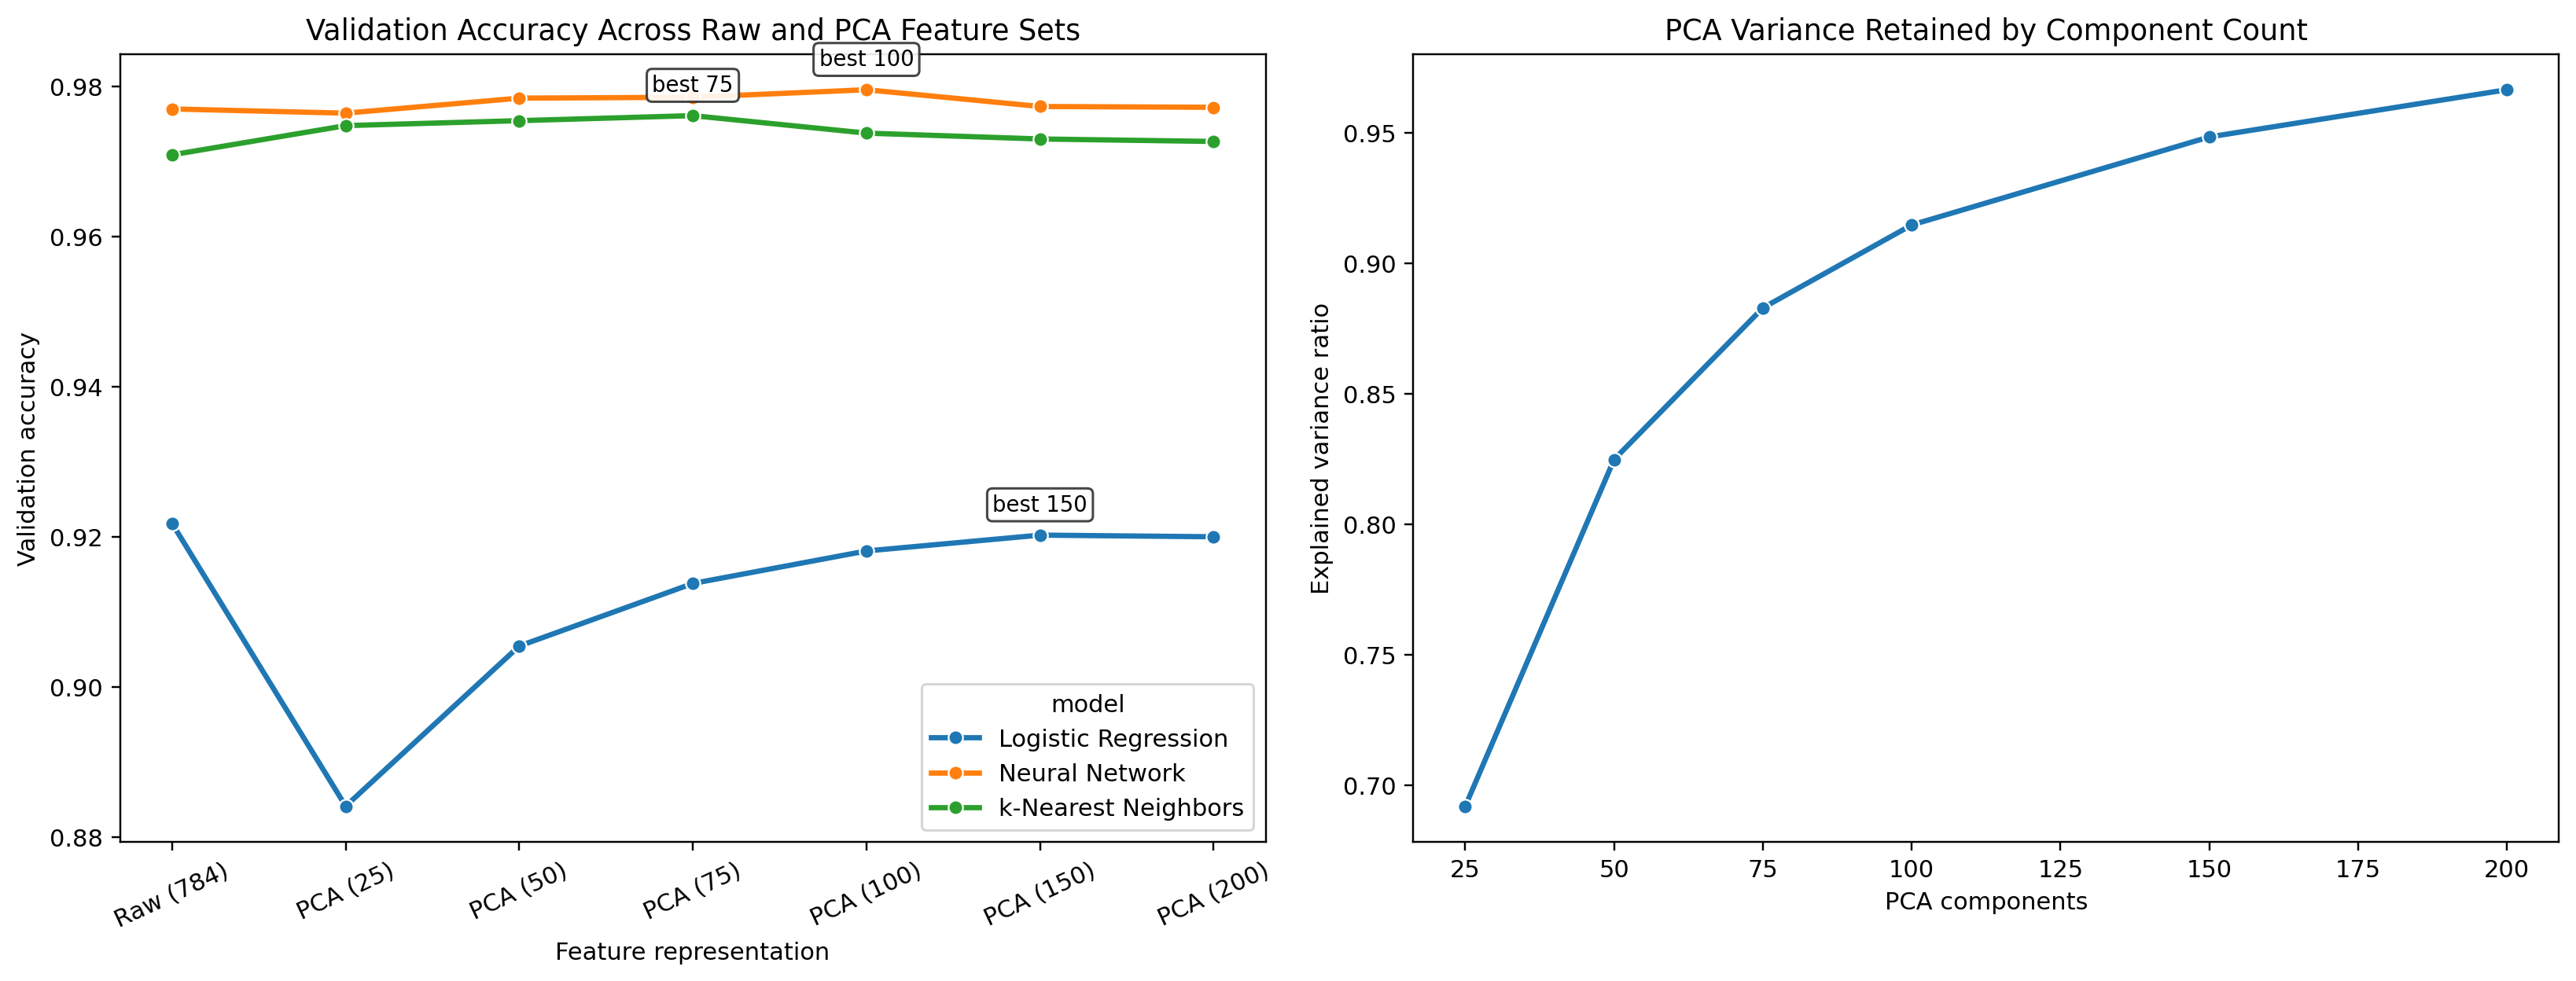

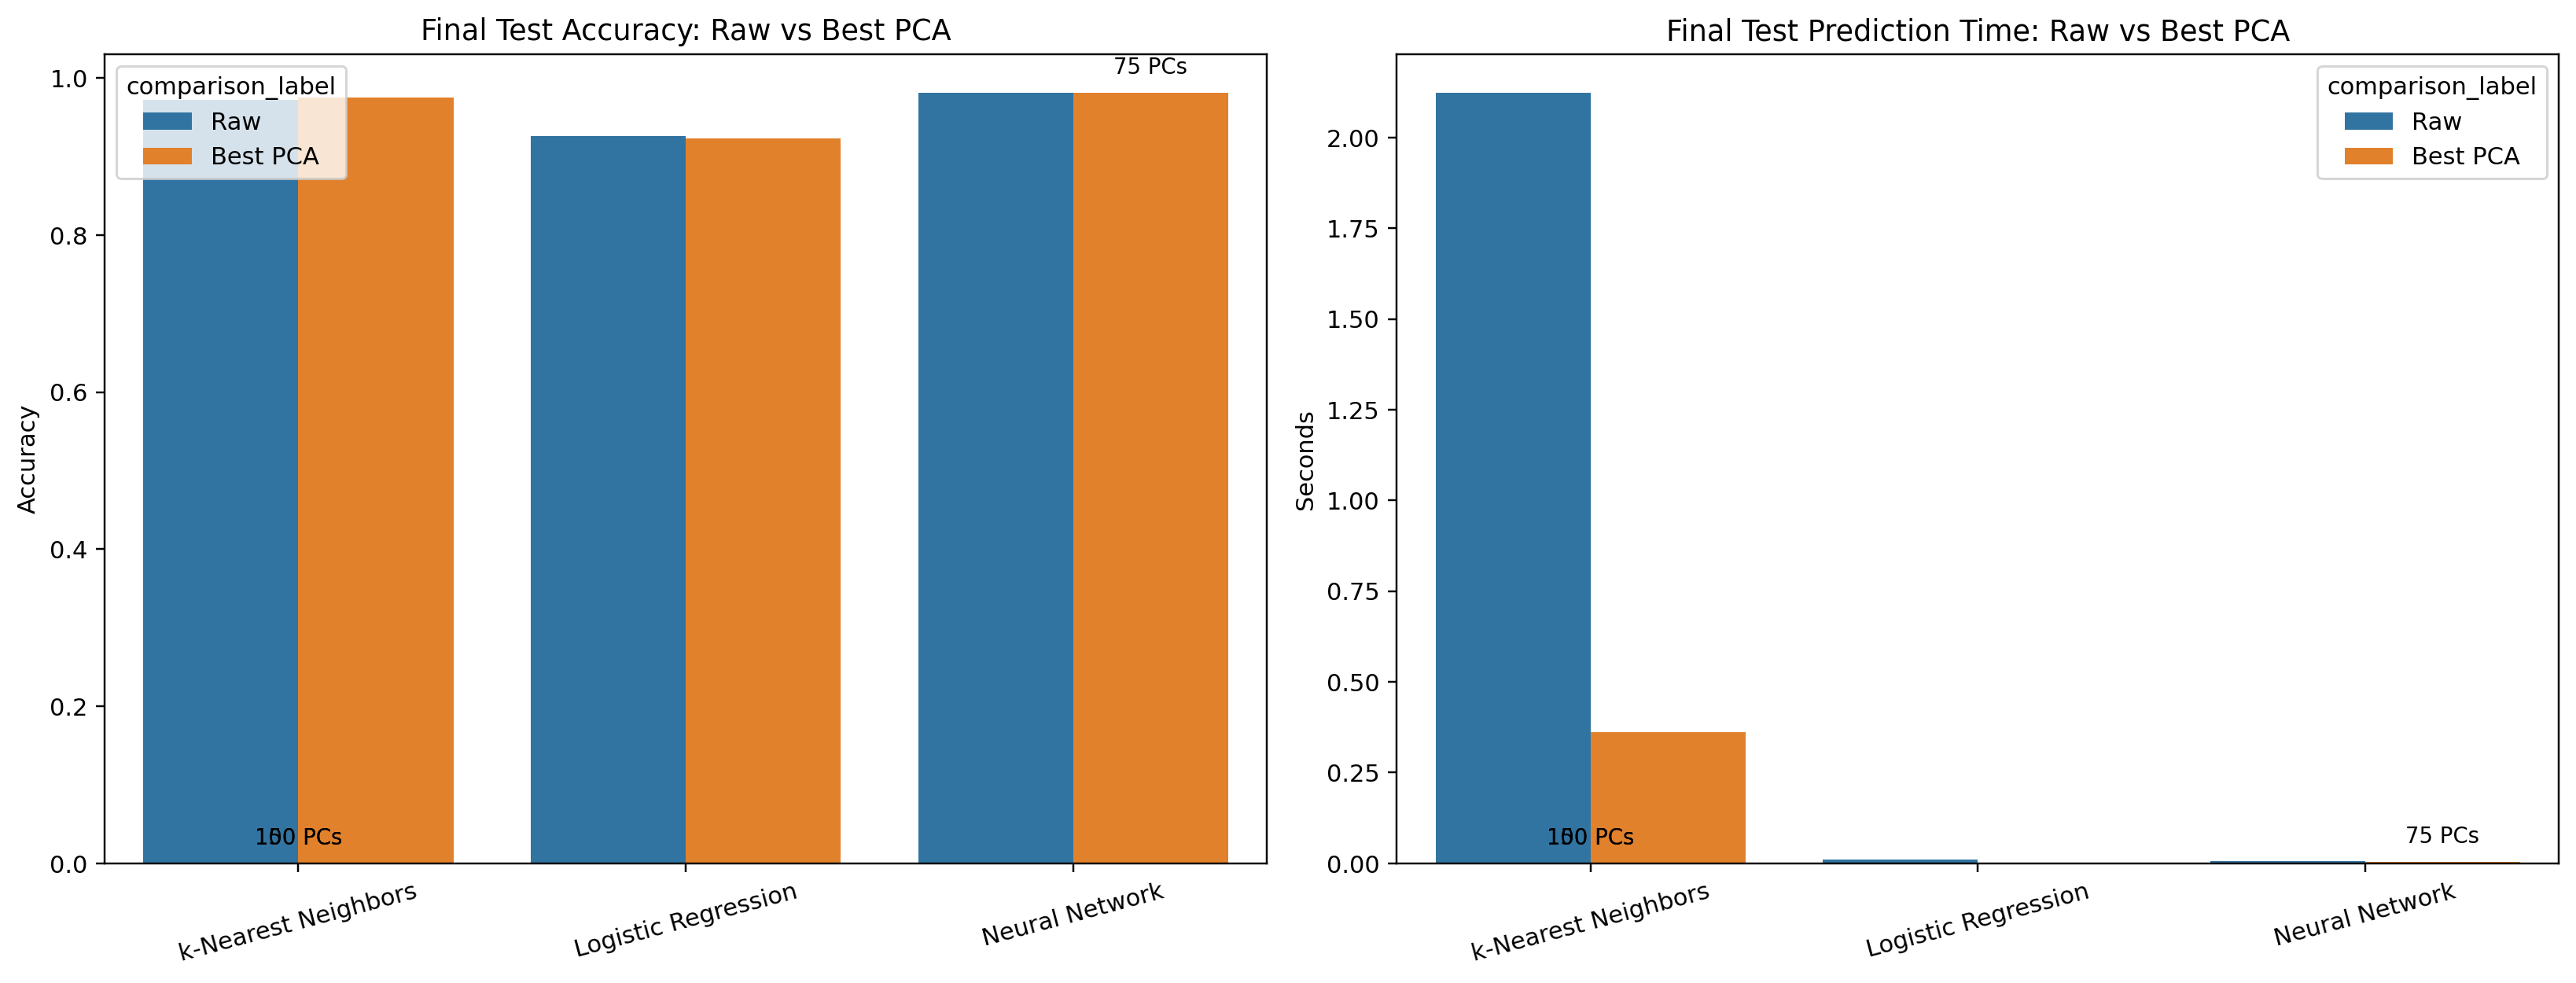

In [8]:
benchmark_summary_path = config.results_dir / 'raw_vs_best_pca_test_summary.csv'
display(pd.read_csv(benchmark_summary_path))
display(Image(filename=str(config.figures_dir / 'pca_component_benchmark.png')))
display(Image(filename=str(config.figures_dir / 'raw_vs_best_pca_dashboard.png')))

knn_confusion_matrix.png


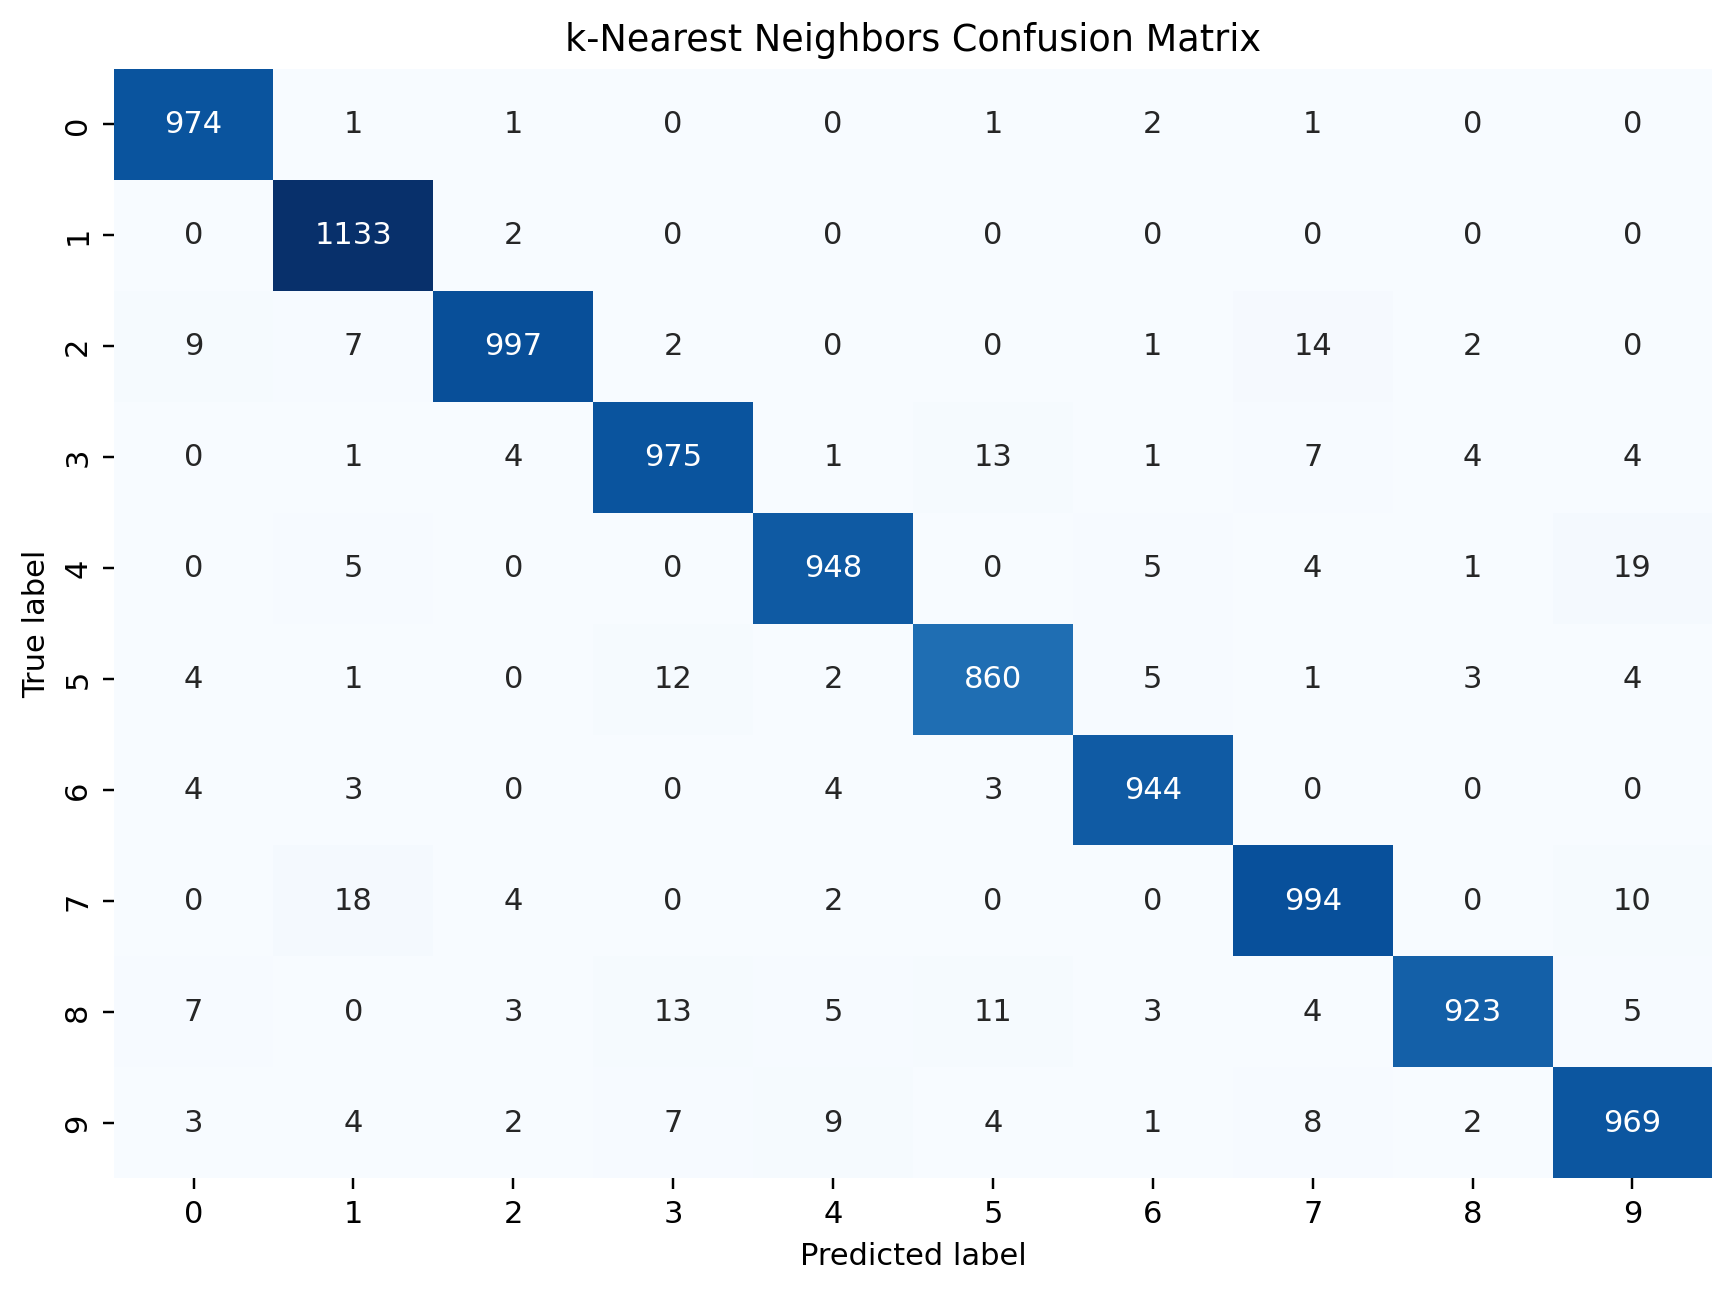

logistic_regression_confusion_matrix.png


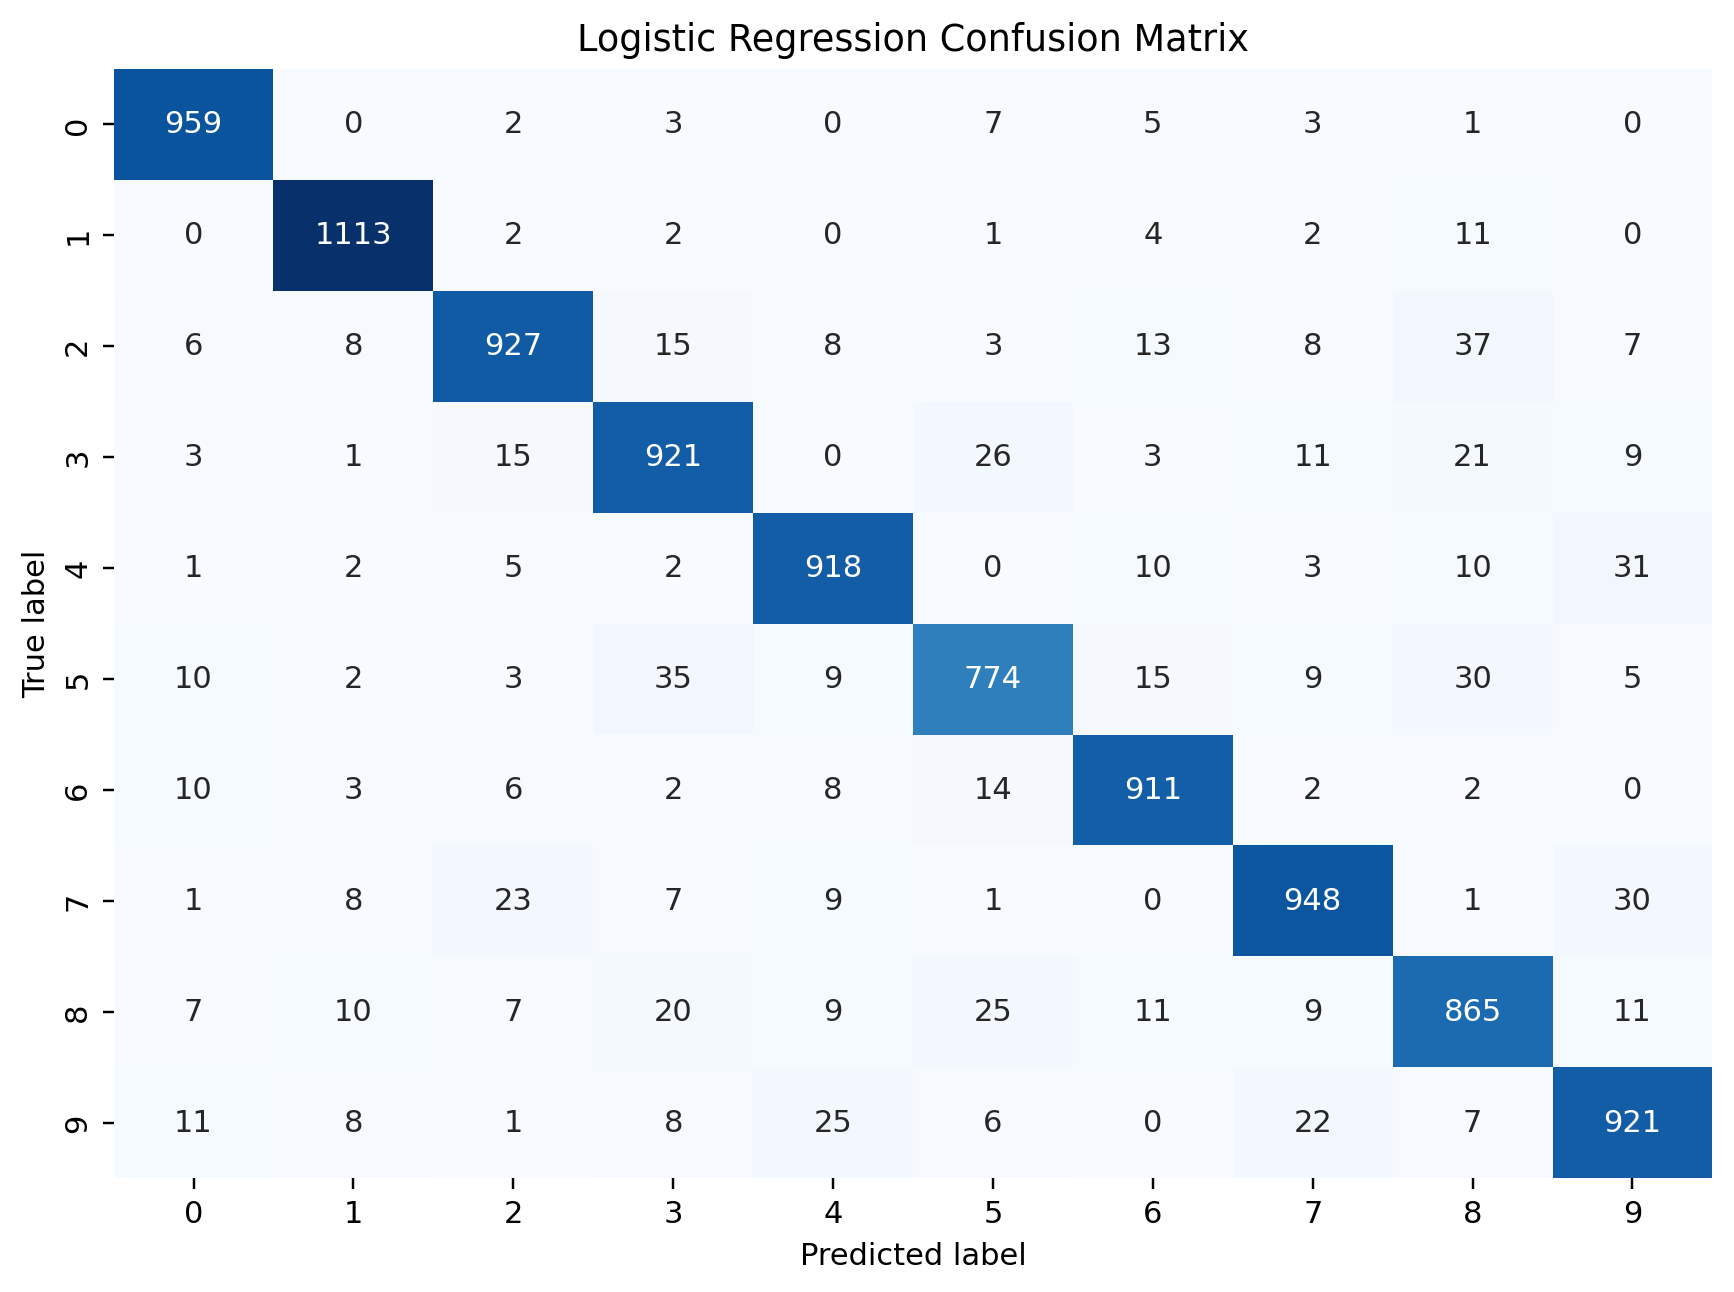

neural_network_confusion_matrix.png


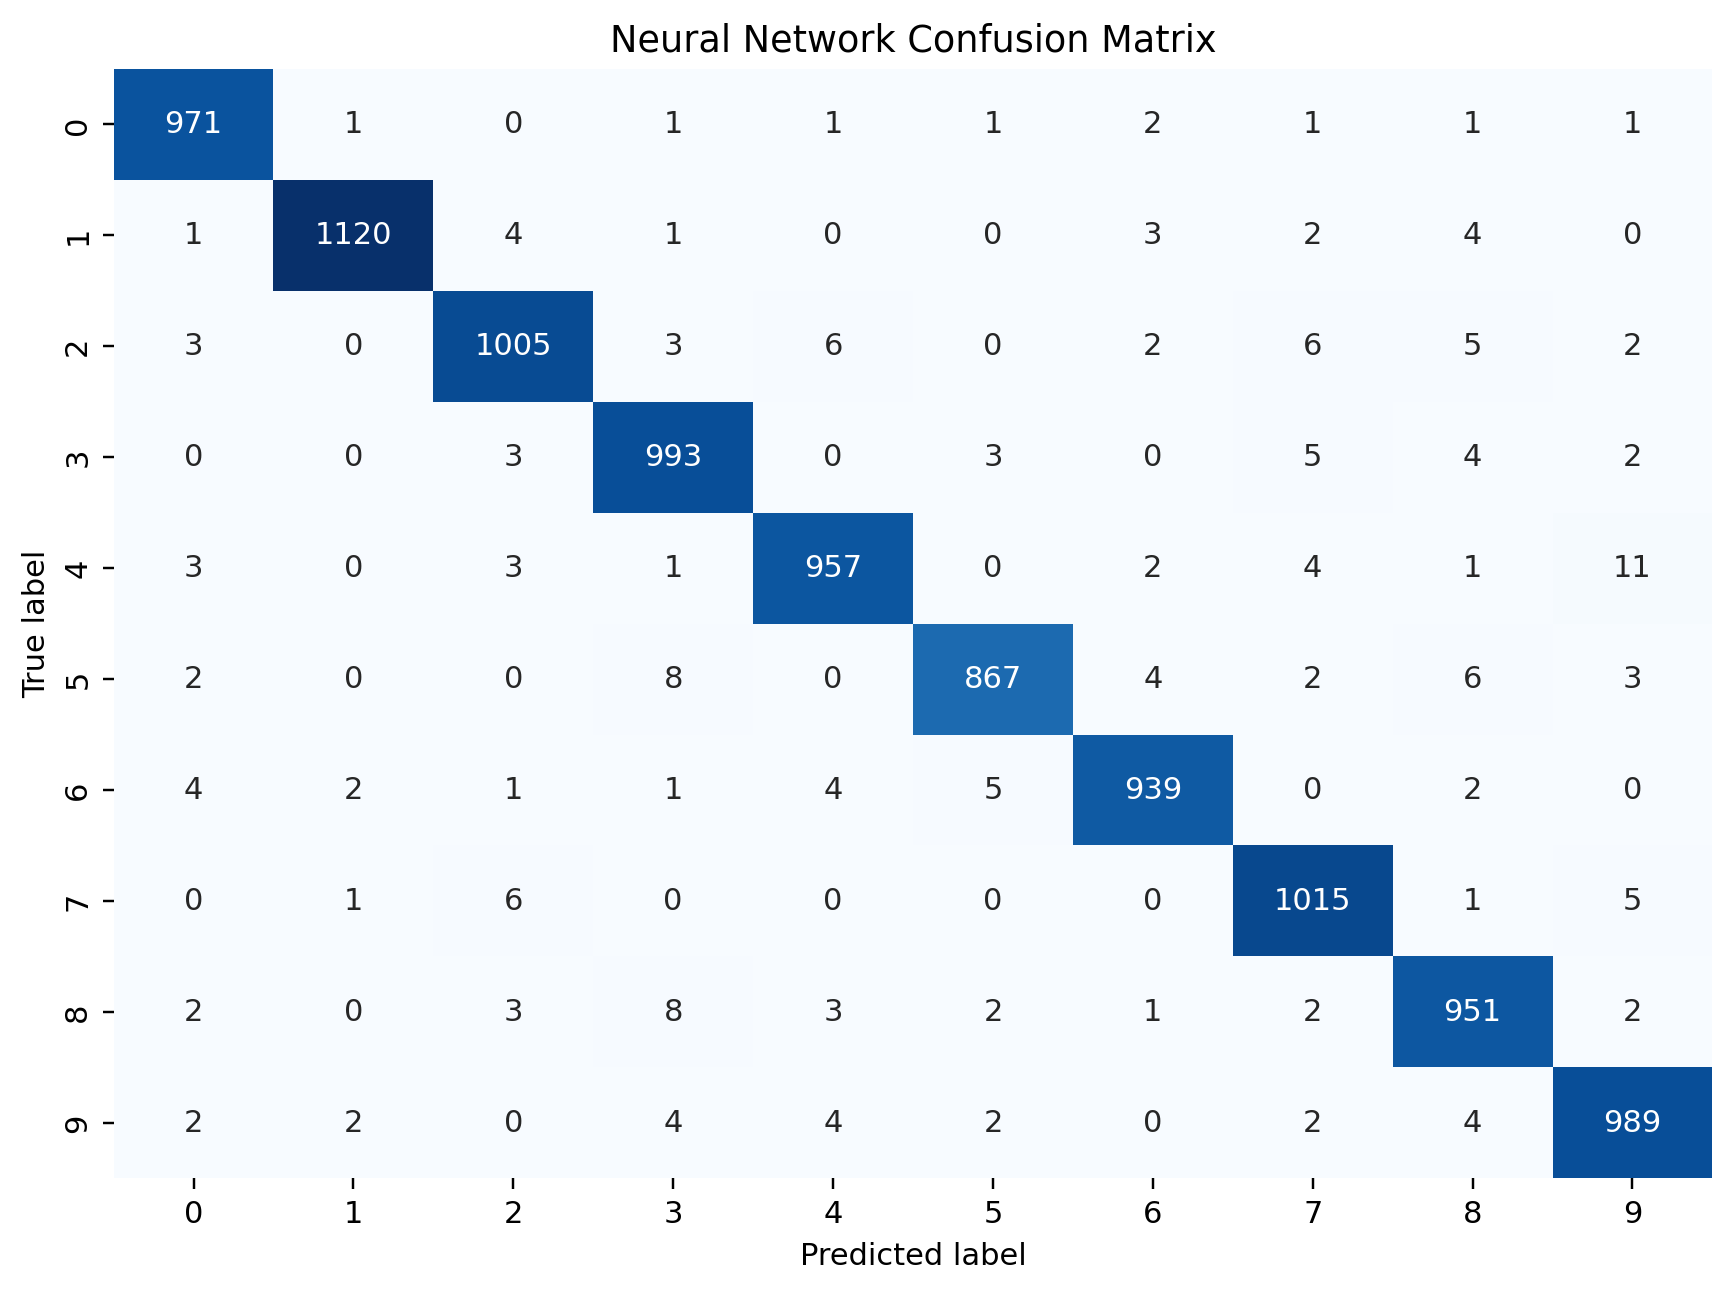

In [9]:
for figure_path in sorted(config.figures_dir.glob('*_confusion_matrix.png')):
    print(figure_path.name)
    display(Image(filename=str(figure_path)))

In [10]:
print('Artifacts:')
for path in sorted(config.figures_dir.iterdir()):
    print(path.relative_to(project_root))
for path in sorted(config.results_dir.iterdir()):
    print(path.relative_to(project_root))

Artifacts:
artifacts/figures/data_split_protocol.png
artifacts/figures/digits_pca_2d.png
artifacts/figures/digits_tsne_2d.png
artifacts/figures/knn_confusing_samples.png
artifacts/figures/knn_confusion_matrix.png
artifacts/figures/knn_hyperparameter_search.png
artifacts/figures/logistic_regression_confusing_samples.png
artifacts/figures/logistic_regression_confusion_matrix.png
artifacts/figures/logistic_regression_hyperparameter_search.png
artifacts/figures/model_comparison_dashboard.png
artifacts/figures/neural_network_architecture.png
artifacts/figures/neural_network_confusing_samples.png
artifacts/figures/neural_network_confusion_matrix.png
artifacts/figures/neural_network_hyperparameter_search.png
artifacts/figures/neural_network_training_curve.png
artifacts/figures/pca_component_benchmark.png
artifacts/figures/raw_vs_best_pca_dashboard.png
artifacts/figures/sample_digits.png
artifacts/results/data_split_summary.csv
artifacts/results/knn_classification_report.csv
artifacts/results/